In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/cleaned/master_dataset.csv')
print(df.shape)
df.head()

(117891, 35)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_score,order_year_month,delivery_delay_days,total_item_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,sao paulo,SP,1.0,credit_card,1.0,18.12,4.0,2017-10,-8.0,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,sao paulo,SP,3.0,voucher,1.0,2.00,4.0,2017-10,-8.0,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,sao paulo,SP,2.0,voucher,1.0,18.59,4.0,2017-10,-8.0,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,barreiras,BA,1.0,boleto,1.0,141.46,4.0,2018-07,-6.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,vianopolis,GO,1.0,credit_card,3.0,179.12,5.0,2018-08,-18.0,179.12


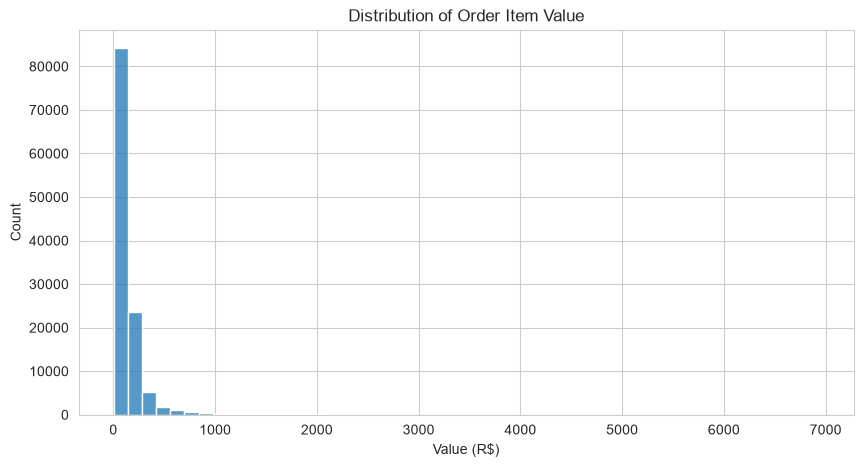

In [2]:
plt.figure()
sns.histplot(df['total_item_value'], bins=50)
plt.title('Distribution of Order Item Value')
plt.xlabel('Value (R$)')
plt.show()

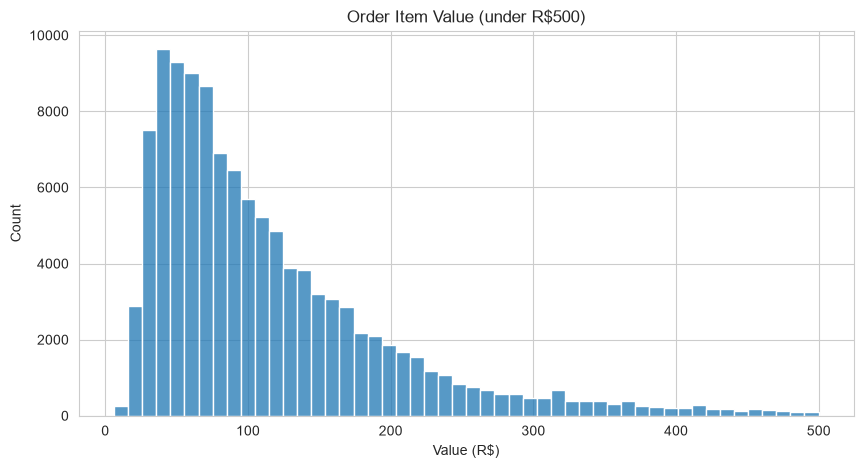

In [3]:
plt.figure()
sns.histplot(df[df['total_item_value'] < 500]['total_item_value'], bins=50)
plt.title('Order Item Value (under R$500)')
plt.xlabel('Value (R$)')
plt.show()

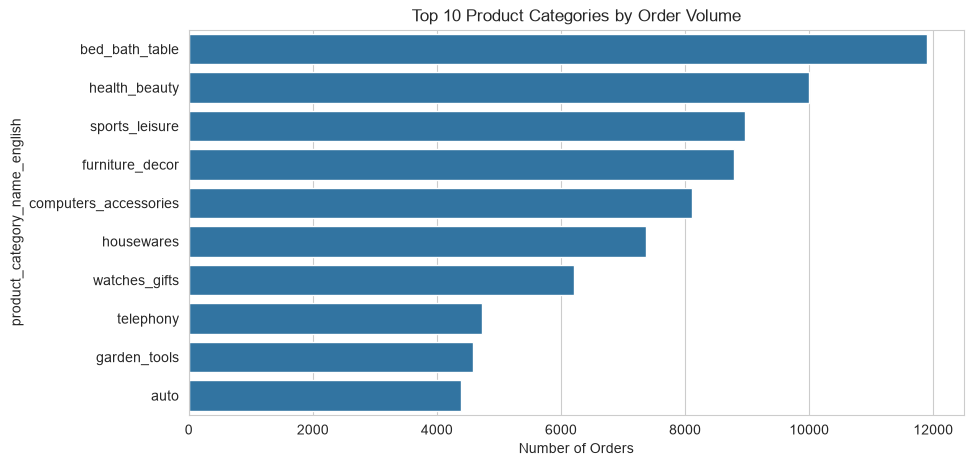

In [4]:
top_categories = df['product_category_name_english'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title('Top 10 Product Categories by Order Volume')
plt.xlabel('Number of Orders')
plt.show()

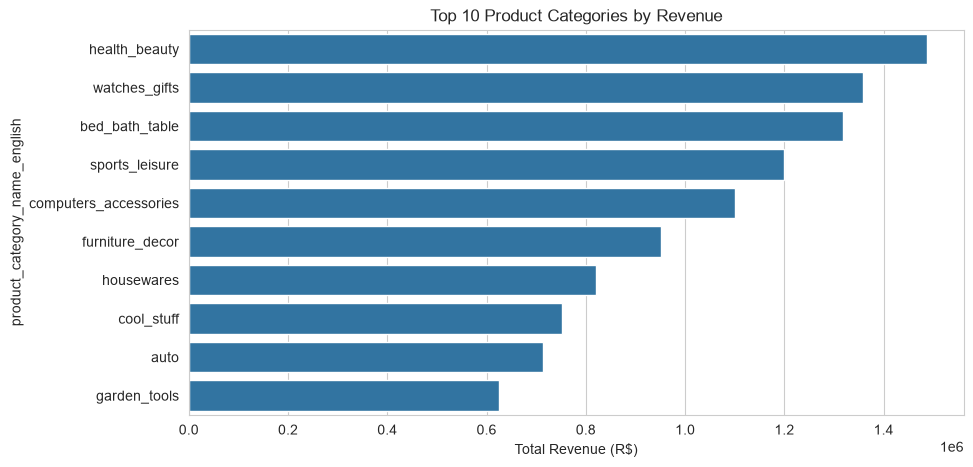

In [12]:
revenue_by_category = (
    df.groupby('product_category_name_english')['total_item_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index)
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue (R$)')
plt.savefig('../docs/images/top_categories_revenue.png')
plt.show()

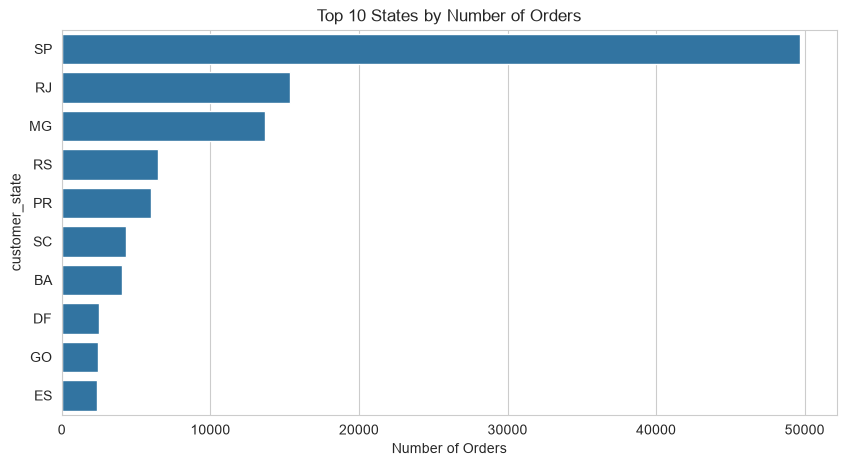

In [6]:
top_states = df['customer_state'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_states.values, y=top_states.index)
plt.title('Top 10 States by Number of Orders')
plt.xlabel('Number of Orders')
plt.show()

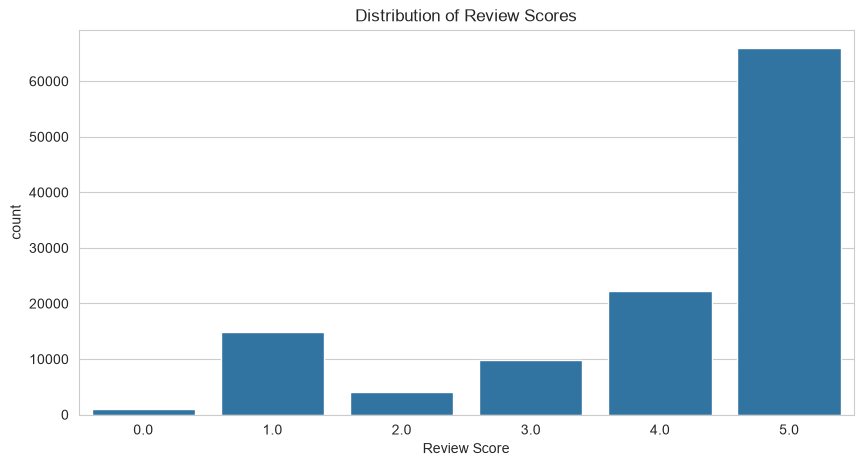

In [13]:
plt.figure()
sns.countplot(x='review_score', data=df, order=sorted(df['review_score'].unique()))
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.savefig('../docs/images/review_score_distribution.png', bbox_inches='tight')
plt.show()

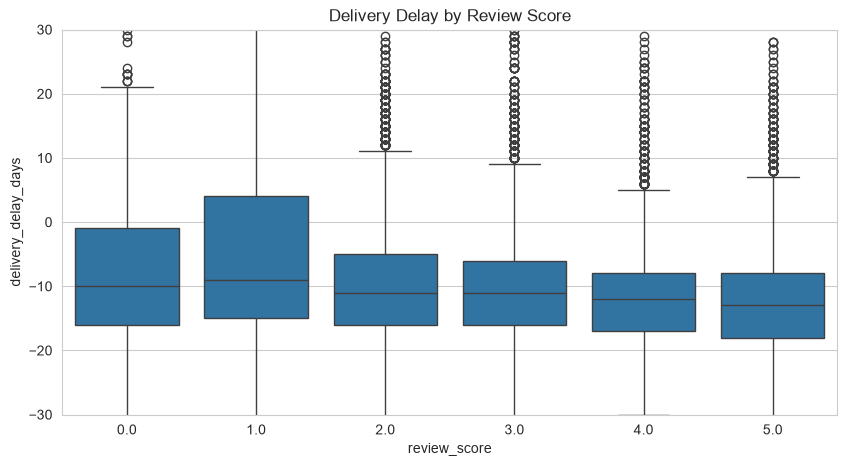

In [8]:
plt.figure()
sns.boxplot(x='review_score', y='delivery_delay_days', data=df)
plt.title('Delivery Delay by Review Score')
plt.ylim(-30, 30)
plt.show()

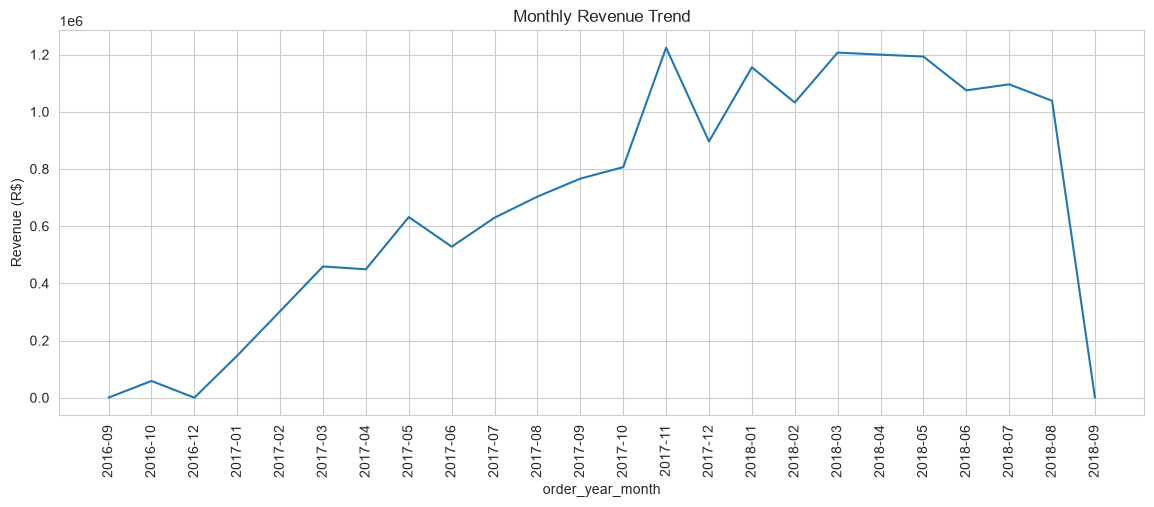

In [14]:
monthly_sales = df.groupby('order_year_month')['total_item_value'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(x='order_year_month', y='total_item_value', data=monthly_sales)
plt.xticks(rotation=90)
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (R$)')
plt.savefig('../docs/images/monthly_revenue_trend.png', bbox_inches='tight')
plt.show()

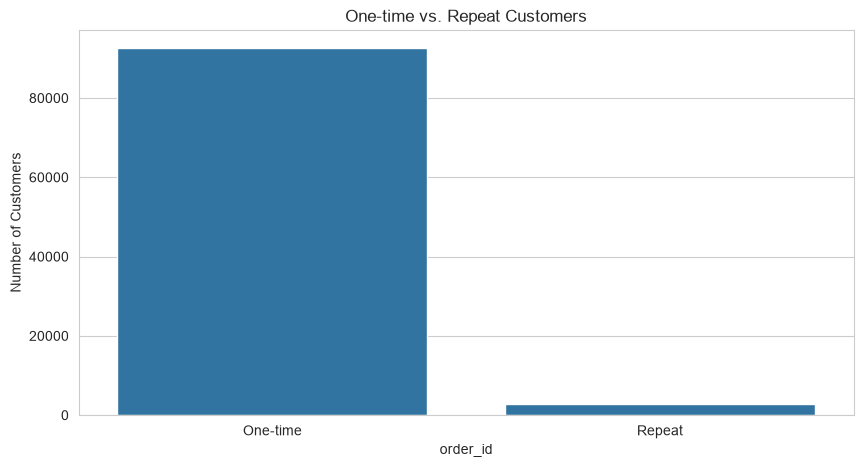

order_id
One-time    92507
Repeat       2913
Name: count, dtype: int64


In [15]:
orders_per_customer = df.groupby('customer_unique_id')['order_id'].nunique()

repeat_vs_onetime = pd.cut(
    orders_per_customer,
    bins=[0, 1, orders_per_customer.max()],
    labels=['One-time', 'Repeat']
).value_counts()

plt.figure()
sns.barplot(x=repeat_vs_onetime.index, y=repeat_vs_onetime.values)
plt.title('One-time vs. Repeat Customers')
plt.ylabel('Number of Customers')
plt.savefig('../docs/images/repeat_vs_onetime.png', bbox_inches='tight')
plt.show()

print(repeat_vs_onetime)

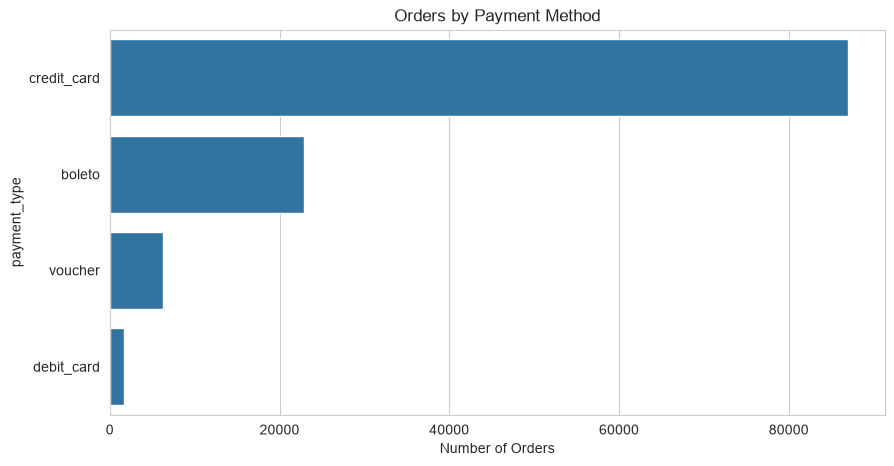

In [11]:
payment_counts = df['payment_type'].value_counts()

plt.figure()
sns.barplot(x=payment_counts.values, y=payment_counts.index)
plt.title('Orders by Payment Method')
plt.xlabel('Number of Orders')
plt.show()

In [16]:
# Top categories by volume vs revenue
print("TOP 3 BY VOLUME:")
print(df['product_category_name_english'].value_counts().head(3))

print("\nTOP 3 BY REVENUE:")
print(df.groupby('product_category_name_english')['total_item_value'].sum().sort_values(ascending=False).head(3))

# Repeat customer percentage
orders_per_customer = df.groupby('customer_unique_id')['order_id'].nunique()
repeat_pct = (orders_per_customer > 1).mean() * 100
print(f"\nREPEAT CUSTOMER %: {repeat_pct:.1f}%")

# Payment method percentage
print("\nPAYMENT METHOD %:")
print((df['payment_type'].value_counts(normalize=True) * 100).round(1))

# Monthly revenue trend (first vs last few months)
monthly_sales = df.groupby('order_year_month')['total_item_value'].sum()
print("\nMONTHLY REVENUE (first 5 months):")
print(monthly_sales.head())
print("\nMONTHLY REVENUE (last 5 months):")
print(monthly_sales.tail())

TOP 3 BY VOLUME:
product_category_name_english
bed_bath_table    11898
health_beauty      9990
sports_leisure     8958
Name: count, dtype: int64

TOP 3 BY REVENUE:
product_category_name_english
health_beauty     1487194.54
watches_gifts     1358593.59
bed_bath_table    1317200.10
Name: total_item_value, dtype: float64

REPEAT CUSTOMER %: 3.1%

PAYMENT METHOD %:
payment_type
credit_card    73.8
boleto         19.5
voucher         5.3
debit_card      1.4
Name: proportion, dtype: float64

MONTHLY REVENUE (first 5 months):
order_year_month
2016-09       354.75
2016-10     58550.03
2016-12        19.62
2017-01    147144.50
2017-02    302466.08
Name: total_item_value, dtype: float64

MONTHLY REVENUE (last 5 months):
order_year_month
2018-05    1192962.17
2018-06    1074756.08
2018-07    1095797.22
2018-08    1038351.29
2018-09        166.46
Name: total_item_value, dtype: float64


## Key EDA Findings

- The top categories by order volume are bed_bath_table, health_beauty, and sports_leisure, but by revenue the ranking shifts to health_beauty, watches_gifts, and bed_bath_table — watches_gifts sells fewer units but at a higher price point, pushing it into the top 3 by revenue despite not appearing in the top 3 by volume.
- Only about 3.1% of customers are repeat buyers; the vast majority (96.9%) purchase only once — a strong signal that customer retention, not just acquisition, is a major opportunity area for this business.
- Review scores drop noticeably as delivery delay increases, confirming late delivery is a major driver of dissatisfaction.
- Credit card is the dominant payment method at roughly 73.8% of orders, followed by boleto (a Brazilian bank slip payment method) at 19.5%, voucher at 5.3%, and debit card at just 1.4%.
- Monthly revenue grew sharply from late 2016 (under R$1,000/month) to a peak around R$1.0–1.2M/month by mid-2018, showing strong platform growth over the ~2-year window. The very first (2016-09/2016-12) and very last (2018-09) months show unusually low values — likely incomplete data at the start and end of the collection period rather than a real trend, and worth flagging rather than treating as a genuine dip.